In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
# Unzip dataset from Google Drive
!unzip -q "/content/drive/MyDrive/Dataset/aptos2019-blindness-detection.zip" -d /content/aptos_data
print("Dataset extracted successfully.")

Dataset extracted successfully.


In [6]:
# Check extracted files
!ls /content/aptos_data

sample_submission.csv  test.csv  test_images  train.csv  train_images


In [7]:
# Optional: check train images folder
!ls /content/aptos_data/train_images | head

000c1434d8d7.png
001639a390f0.png
0024cdab0c1e.png
002c21358ce6.png
005b95c28852.png
0083ee8054ee.png
0097f532ac9f.png
00a8624548a9.png
00b74780d31d.png
00cb6555d108.png


In [ ]:
import os
import copy
import random #path handling
import numpy as np
import pandas as pd #array, matrix, number calculation এর জন্য।
from PIL import Image # image processing এর জন্য।

import torch
import torch.nn as nn
import torch.optim as optim #সব tensor operation, GPU use, model save/load এগুলোর base।
from torch.utils.data import Dataset, DataLoader, Subset
import torchvision.transforms as transforms # image preprocessing এর জন্য।

import matplotlib.pyplot as plt
import seaborn as sns # visualization এর জন্য।

from sklearn.metrics import (#এগুলো model evaluation এর জন্য।
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_recall_fscore_support
)

from IPython.display import display# Jupyter notebook এ output display করার জন্য।

try:
    from torchsummary import summary# model architecture summary দেখানোর জন্য।
except:
    !pip -q install torchsummary# torchsummary ইনস্টল করার জন্য।
    from torchsummary import summary

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [ ]:
# =========================================================
# Hyperparameters and Custom Dataset class
#traing er important set করছে
# =========================================================
batch_size = 32 #model training এর সময় একবারে কতগুলো sample দিয়ে update করতে হবে।
learning_rate = 0.001
minimum_learning_rate = 1e-5
epochs = 15
num_classes = 5
image_size = 128
random_seed = 42 # এটা reproducibility এর জন্য। and mane datasuffle,random split,intialization

#এখানে 3 জায়গার randomness control করা হচ্ছে:
torch.manual_seed(random_seed)
np.random.seed(random_seed)
random.seed(random_seed)

#GPU থাকলে তার randomness control করা হচ্ছে:
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(random_seed)

# Custom Dataset class for APTOS 2019
class APTOSDataset(Dataset):
    def __init__(self, csv_file, root_dir, transform=None):#
        self.data_df = pd.read_csv(csv_file)#যে CSV file এ image id আর label আছে
        self.root_dir = root_dir #যে folder এ image গুলো আছে
        self.transform = transform#image preprocessing এর জন্য

    def __len__(self):#dataset এর total sample count return করে
        return len(self.data_df)

    def __getitem__(self, idx):
        img_id = self.data_df.iloc[idx]["id_code"] #CSV এর idx number row থেকে image id নিচ্ছে।
        label = int(self.data_df.iloc[idx]["diagnosis"]) #CSV এর idx number row থেকে label নিচ্ছে।

        img_path = os.path.join(self.root_dir, img_id + ".png")
        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label

print("Hyperparameters:")
print(f"Batch Size           : {batch_size}")
print(f"Learning Rate        : {learning_rate}")
print(f"Minimum Learning Rate: {minimum_learning_rate}")
print(f"Epochs               : {epochs}")
print(f"Number of Classes    : {num_classes}")
print(f"Image Size           : {image_size}x{image_size}")

Hyperparameters:
Batch Size           : 32
Learning Rate        : 0.001
Minimum Learning Rate: 1e-05
Epochs               : 15
Number of Classes    : 5
Image Size           : 128x128


In [ ]:
# =========================================================
# Data Loading, Preprocessing, Splitting, and DataLoaders
# =========================================================

train_transform = transforms.Compose([#image preprocessing এর জন্য।
    transforms.Resize((image_size, image_size)),# image size 128x128 এ রিসাইজ করছে
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.15),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

eval_transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],#👉 pixel value scale করে
                         [0.229, 0.224, 0.225])
])

csv_path = "/content/aptos_data/train.csv"
img_dir = "/content/aptos_data/train_images"

train_dataset_full = APTOSDataset(csv_path, img_dir, transform=train_transform)#full dataset augmentation সহ তৈরি করছে
eval_dataset_full  = APTOSDataset(csv_path, img_dir, transform=eval_transform)#full dataset শুধু normalization সহ তৈরি করছে

dataset_df = pd.read_csv(csv_path)
print("Dataset shape:", dataset_df.shape)##👉 মোট row + column দেখাচ্ছে
print("\nClass distribution:")
display(dataset_df["diagnosis"].value_counts().sort_index().to_frame(name="count"))

dataset_size = len(dataset_df)
indices = np.arange(dataset_size)
np.random.shuffle(indices)

train_end = int(0.70 * dataset_size)
val_end   = int(0.85 * dataset_size)

#👉 dataset 3 ভাগে ভাগ করা হচ্ছে
train_indices = indices[:train_end]
val_indices   = indices[train_end:val_end]
test_indices  = indices[val_end:]

train_data = Subset(train_dataset_full, train_indices)#👉 full dataset থেকে শুধু selected index নিয়ে subset বানানো হচ্ছে
val_data   = Subset(eval_dataset_full, val_indices)
test_data  = Subset(eval_dataset_full, test_indices)

#👉 model training এর জন্য final data pipeline
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_data, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_data, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

print(f"\nTotal samples      : {dataset_size}")
print(f"Training samples   : {len(train_data)}")
print(f"Validation samples : {len(val_data)}")
print(f"Test samples       : {len(test_data)}")

Dataset shape: (3662, 2)

Class distribution:


,count
diagnosis,
0,1805
1,370
2,999
3,193
4,295



Total samples      : 3662
Training samples   : 2563
Validation samples : 549
Test samples       : 550


In [ ]:
# =========================================================
# CNN Architectures
# =========================================================

class CNNWithoutBNDropout(nn.Module):
    def __init__(self, num_classes=5):
        super(CNNWithoutBNDropout, self).__init__()#parent class nn.Module properly setup করার জন্য

        self.features = nn.Sequential(

            #input channel = 3, কারণ RGB image
            #32 ta feature map ber hobe
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),# feature map size 64x64 হবে half of 128

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),# 3d feature map কে 1d vector এ convert করছে
            nn.Linear(128 * 8 * 8, 512),#feature 512 te pathabe
            nn.ReLU(),
            nn.Linear(512, num_classes)# final output layer
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


class CNNWithBNDropout(nn.Module):
    def __init__(self, num_classes=5):
        super(CNNWithBNDropout, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 8 * 8, 512),
            nn.ReLU(),
            nn.Dropout(0.5),# training এর সময় random কিছু neuron বন্ধ করে দেয় like 50%
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


baseline_model = CNNWithoutBNDropout(num_classes=num_classes).to(device)
regularized_model = CNNWithBNDropout(num_classes=num_classes).to(device)

print("Baseline Model Summary (Without BatchNorm and Dropout)")
summary(baseline_model, input_size=(3, image_size, image_size))

print("\n" + "=" * 70 + "\n")

print("Regularized Model Summary (With BatchNorm and Dropout)")
summary(regularized_model, input_size=(3, image_size, image_size))

Baseline Model Summary (Without BatchNorm and Dropout)
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 32, 128, 128]             896
              ReLU-2         [-1, 32, 128, 128]               0
         MaxPool2d-3           [-1, 32, 64, 64]               0
            Conv2d-4           [-1, 64, 64, 64]          18,496
              ReLU-5           [-1, 64, 64, 64]               0
         MaxPool2d-6           [-1, 64, 32, 32]               0
            Conv2d-7          [-1, 128, 32, 32]          73,856
              ReLU-8          [-1, 128, 32, 32]               0
         MaxPool2d-9          [-1, 128, 16, 16]               0
           Conv2d-10          [-1, 128, 16, 16]         147,584
             ReLU-11          [-1, 128, 16, 16]               0
        MaxPool2d-12            [-1, 128, 8, 8]               0
          Flatten-13                 [-1, 8192] 

In [ ]:
# =========================================================
# Training and Evaluation Functions
# =========================================================
# optimizer weight update
# criterion loass function

def train_epoch(model, loader, optimizer, criterion, device):
    model.train()  # training mode (Dropout/BatchNorm active)

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)  # move to device

        optimizer.zero_grad()  # clear old gradients
        outputs = model(images)  # forward pass
        loss = criterion(outputs, labels)  # compute loss

        loss.backward()  # backpropagation (compute gradients)
        optimizer.step()  # update weights

        running_loss += loss.item()  # accumulate loss

        _, preds = torch.max(outputs, 1)  # predicted class
        correct += (preds == labels).sum().item()  # correct count
        total += labels.size(0)  # total samples

    epoch_loss = running_loss / len(loader)  # avg loss
    epoch_acc = correct / total  # accuracy

    return epoch_loss, epoch_acc


def validate_epoch(model, loader, criterion, device):
    model.eval()  # evaluation mode (Dropout off)

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():  # no gradient (faster, memory save)
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)  # forward only
            loss = criterion(outputs, labels)

            running_loss += loss.item()

            _, preds = torch.max(outputs, 1)  # predicted class
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    epoch_loss = running_loss / len(loader)
    epoch_acc = correct / total

    return epoch_loss, epoch_acc


def train_model(model, train_loader, val_loader, device, epochs, learning_rate, minimum_learning_rate, checkpoint_name):

    criterion = nn.CrossEntropyLoss()  # multi-class loss
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)  # optimizer

    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)
    # reduce LR every 5 epochs

    model, optimizer, scheduler, start_epoch, history, best_val_acc, best_model_wts = load_checkpoint(
        model, optimizer, scheduler, checkpoint_name, device
    )  # resume training

    for epoch in range(start_epoch, epochs):

        train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion, device)
        val_loss, val_acc = validate_epoch(model, val_loader, criterion, device)

        scheduler.step()  # update LR

        if optimizer.param_groups[0]["lr"] < minimum_learning_rate:
            optimizer.param_groups[0]["lr"] = minimum_learning_rate  # LR lower bound

        history["train_loss"].append(train_loss)  # store for plot
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print(f"Epoch [{epoch+1}/{epochs}]")
        print(f"Train Loss: {train_loss:.4f} | Train Accuracy: {train_acc:.4f}")
        print(f"Val   Loss: {val_loss:.4f} | Val   Accuracy: {val_acc:.4f}")
        print(f"Current LR: {optimizer.param_groups[0]['lr']:.6f}")

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_wts = copy.deepcopy(model.state_dict())  # save best model

        save_checkpoint(
            epoch,
            model,
            optimizer,
            scheduler,
            history,
            best_val_acc,
            best_model_wts,
            checkpoint_name
        )  # save progress

    model.load_state_dict(best_model_wts)  # load best weights

    return model, history, best_val_acc


def evaluate_model(model, loader, device):
    model.eval()  # evaluation mode

    all_labels = []
    all_preds = []

    with torch.no_grad():  # no gradient
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            _, preds = torch.max(outputs, 1)  # predicted class

            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())

    accuracy = accuracy_score(all_labels, all_preds)  # accuracy

    precision, recall, f1, _ = precision_recall_fscore_support(
        all_labels, all_preds, average="weighted", zero_division=0
    )  # weighted metrics

    return all_labels, all_preds, accuracy, precision, recall, f1

In [ ]:
# =========================================================
# Checkpoint Save / Load Utilities
# =========================================================

import os
import copy
import torch

CHECKPOINT_DIR = "/content/drive/MyDrive/cvpr_checkpoints"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)  # create folder if not exists


def save_checkpoint(epoch, model, optimizer, scheduler, history, best_val_acc, best_model_wts, filename):
    checkpoint_path = os.path.join(CHECKPOINT_DIR, filename)  # full checkpoint path

    torch.save({
        "epoch": epoch,  # current epoch number
        "model_state_dict": model.state_dict(),  # model weights
        "optimizer_state_dict": optimizer.state_dict(),  # optimizer state
        "scheduler_state_dict": scheduler.state_dict(),  # scheduler state
        "history": history,  # loss and accuracy history
        "best_val_acc": best_val_acc,  # best validation accuracy
        "best_model_wts": best_model_wts  # best model weights
    }, checkpoint_path)

    print(f"Checkpoint saved at epoch {epoch+1}: {checkpoint_path}")  # save confirmation


def load_checkpoint(model, optimizer, scheduler, filename, device):
    checkpoint_path = os.path.join(CHECKPOINT_DIR, filename)  # full checkpoint path

    if not os.path.exists(checkpoint_path):
        print(f"No checkpoint found for {filename}. Training will start from epoch 1.")  # start fresh

        history = {
            "train_loss": [],
            "train_acc": [],
            "val_loss": [],
            "val_acc": []
        }  # empty history

        best_val_acc = 0.0  # initial best accuracy
        best_model_wts = copy.deepcopy(model.state_dict())  # initial model weights
        start_epoch = 0  # start from first epoch

        return model, optimizer, scheduler, start_epoch, history, best_val_acc, best_model_wts

    checkpoint = torch.load(checkpoint_path, map_location=device)  # load checkpoint to CPU/GPU

    model.load_state_dict(checkpoint["model_state_dict"])  # restore model weights
    optimizer.load_state_dict(checkpoint["optimizer_state_dict"])  # restore optimizer state
    scheduler.load_state_dict(checkpoint["scheduler_state_dict"])  # restore scheduler state

    history = checkpoint["history"]  # restore training history
    best_val_acc = checkpoint["best_val_acc"]  # restore best validation accuracy
    best_model_wts = checkpoint["best_model_wts"]  # restore best model weights
    start_epoch = checkpoint["epoch"] + 1  # continue from next epoch

    print(f"Checkpoint loaded: {checkpoint_path}")  # load confirmation
    print(f"Resuming from epoch {start_epoch + 1}")  # resume info

    return model, optimizer, scheduler, start_epoch, history, best_val_acc, best_model_wts

In [ ]:
# =========================================================
# Train Both Models
# =========================================================

print("Training Baseline Model (Without BatchNorm and Dropout)\n")  # start baseline training

baseline_model, baseline_history, baseline_best_val_acc = train_model(
    baseline_model,              # baseline CNN model
    train_loader,                # training data
    val_loader,                  # validation data
    device,                      # CPU/GPU
    epochs,                      # total epochs
    learning_rate,               # initial learning rate
    minimum_learning_rate,       # lower bound of learning rate
    "baseline_checkpoint.pth"    # checkpoint file name
)

print("\n" + "=" * 80 + "\n")  # separator for clear output

print("Training Regularized Model (With BatchNorm and Dropout)\n")  # start regularized training

regularized_model, regularized_history, regularized_best_val_acc = train_model(
    regularized_model,              # regularized CNN model
    train_loader,                   # training data
    val_loader,                     # validation data
    device,                         # CPU/GPU
    epochs,                         # total epochs
    learning_rate,                  # initial learning rate
    minimum_learning_rate,          # lower bound of learning rate
    "regularized_checkpoint.pth"    # checkpoint file name
)

print("\nTraining completed.")  # training finished

print(f"Best Validation Accuracy of Baseline Model   : {baseline_best_val_acc:.4f}")  
# best val accuracy of baseline model

print(f"Best Validation Accuracy of Regularized Model: {regularized_best_val_acc:.4f}")  
# best val accuracy of regularized model

Training Baseline Model (Without BatchNorm and Dropout)

No checkpoint found for baseline_checkpoint.pth. Training will start from epoch 1.
Epoch [1/15]
Train Loss: 0.9683 | Train Accuracy: 0.6567
Val   Loss: 0.8360 | Val   Accuracy: 0.6831
Current Learning Rate: 0.001000
------------------------------------------------------------
Checkpoint saved at epoch 1: /content/drive/MyDrive/cvpr_checkpoints/baseline_checkpoint.pth
Epoch [2/15]
Train Loss: 0.8370 | Train Accuracy: 0.6980
Val   Loss: 0.7889 | Val   Accuracy: 0.6940
Current Learning Rate: 0.001000
------------------------------------------------------------
Checkpoint saved at epoch 2: /content/drive/MyDrive/cvpr_checkpoints/baseline_checkpoint.pth
Epoch [3/15]
Train Loss: 0.8091 | Train Accuracy: 0.7007
Val   Loss: 0.8041 | Val   Accuracy: 0.7031
Current Learning Rate: 0.001000
------------------------------------------------------------
Checkpoint saved at epoch 3: /content/drive/MyDrive/cvpr_checkpoints/baseline_checkpoint.pth

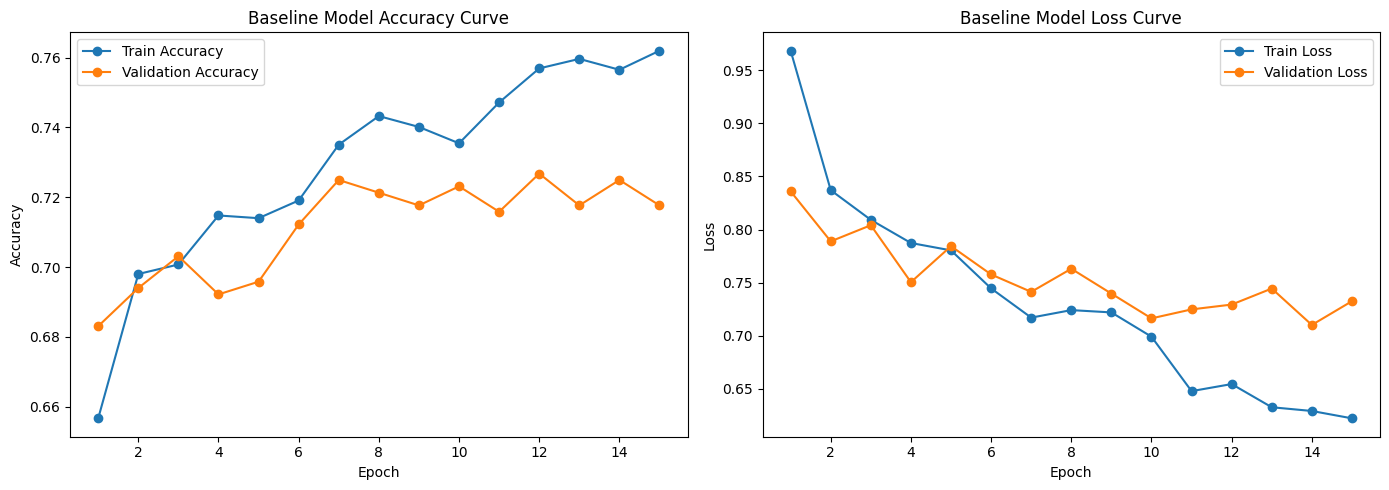

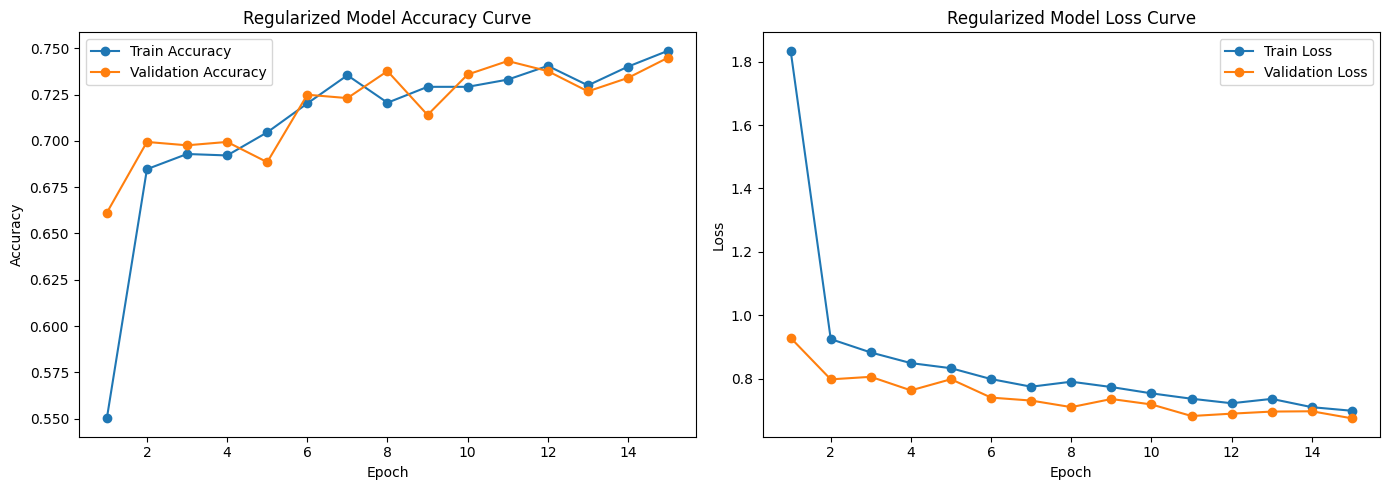

In [17]:
# =========================================================
# Training and Validation Curves
# =========================================================

epochs_range = range(1, epochs + 1)

# Baseline model curves
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, baseline_history["train_acc"], marker='o', label="Train Accuracy")
plt.plot(epochs_range, baseline_history["val_acc"], marker='o', label="Validation Accuracy")
plt.title("Baseline Model Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, baseline_history["train_loss"], marker='o', label="Train Loss")
plt.plot(epochs_range, baseline_history["val_loss"], marker='o', label="Validation Loss")
plt.title("Baseline Model Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

# Regularized model curves
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, regularized_history["train_acc"], marker='o', label="Train Accuracy")
plt.plot(epochs_range, regularized_history["val_acc"], marker='o', label="Validation Accuracy")
plt.title("Regularized Model Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, regularized_history["train_loss"], marker='o', label="Train Loss")
plt.plot(epochs_range, regularized_history["val_loss"], marker='o', label="Validation Loss")
plt.title("Regularized Model Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

Baseline Model Test Results
Accuracy : 0.7436
Precision: 0.7264
Recall   : 0.7436
F1-score : 0.7179

Classification Report (Baseline Model):
              precision    recall  f1-score   support

           0       0.93      0.95      0.94       282
           1       0.41      0.53      0.46        59
           2       0.60      0.75      0.67       136
           3       0.62      0.16      0.26        31
           4       0.29      0.05      0.08        42

    accuracy                           0.74       550
   macro avg       0.57      0.49      0.48       550
weighted avg       0.73      0.74      0.72       550





/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Regularized Model Test Results
Accuracy : 0.7509
Precision: 0.7019
Recall   : 0.7509
F1-score : 0.7159

Classification Report (Regularized Model):
              precision    recall  f1-score   support

           0       0.94      0.96      0.95       282
           1       0.42      0.49      0.45        59
           2       0.58      0.79      0.67       136
           3       0.50      0.13      0.21        31
           4       0.00      0.00      0.00        42

    accuracy                           0.75       550
   macro avg       0.49      0.48      0.46       550
weighted avg       0.70      0.75      0.72       550



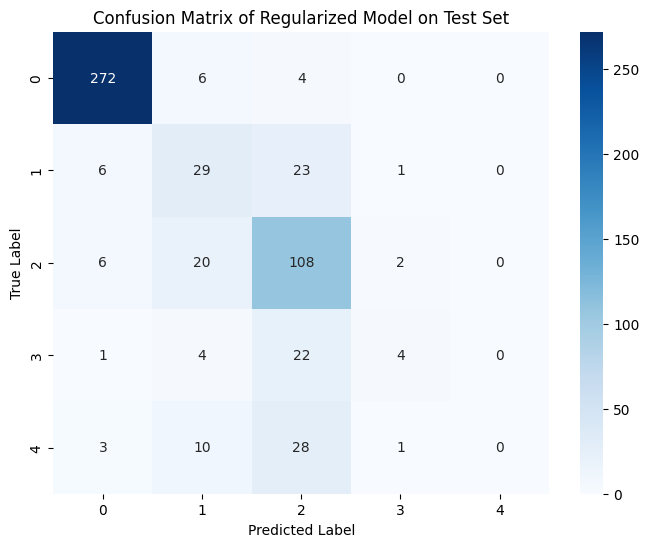

Per-Class F1 Scores:
Class 0: 0.9544
Class 1: 0.4531
Class 2: 0.6729
Class 3: 0.2051
Class 4: 0.0000

Best Performing Class : Class 0 with F1-score = 0.9544
Worst Performing Class: Class 4 with F1-score = 0.0000

Model Comparison Table:


,Model,Accuracy,Precision,Recall,F1-score
0,Baseline (Without BN + Dropout),0.743636,0.726409,0.743636,0.717896
1,Regularized (With BN + Dropout),0.750909,0.701864,0.750909,0.715899


In [ ]:
# =========================================================
# Test Set Evaluation, Confusion Matrix, and Analysis
# =========================================================

# Evaluate baseline model
baseline_labels, baseline_preds, baseline_acc, baseline_precision, baseline_recall, baseline_f1 = evaluate_model(
    baseline_model, test_loader, device
)  # get baseline model predictions and metrics on test set

print("Baseline Model Test Results")
print(f"Accuracy : {baseline_acc:.4f}")    # overall correct prediction rate
print(f"Precision: {baseline_precision:.4f}")  # prediction correctness
print(f"Recall   : {baseline_recall:.4f}")     # actual class recovery rate
print(f"F1-score : {baseline_f1:.4f}")         # balance of precision and recall

print("\nClassification Report (Baseline Model):")
print(classification_report(baseline_labels, baseline_preds, zero_division=0))
# detailed class-wise precision, recall, f1-score

print("\n" + "=" * 80 + "\n")  # separator


# Evaluate regularized model
regularized_labels, regularized_preds, regularized_acc, regularized_precision, regularized_recall, regularized_f1 = evaluate_model(
    regularized_model, test_loader, device
)  # get regularized model predictions and metrics on test set

print("Regularized Model Test Results")
print(f"Accuracy : {regularized_acc:.4f}")
print(f"Precision: {regularized_precision:.4f}")
print(f"Recall   : {regularized_recall:.4f}")
print(f"F1-score : {regularized_f1:.4f}")

print("\nClassification Report (Regularized Model):")
print(classification_report(regularized_labels, regularized_preds, zero_division=0))
# detailed class-wise report for regularized model


# Confusion matrix for regularized model
cm = confusion_matrix(regularized_labels, regularized_preds)  
# shows true class vs predicted class

plt.figure(figsize=(8, 6))  # figure size
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")  
# heatmap visualization of confusion matrix
plt.title("Confusion Matrix of Regularized Model on Test Set")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()


# Per-class performance analysis
report_dict = classification_report(
    regularized_labels,
    regularized_preds,
    output_dict=True,
    zero_division=0
)  # classification report as dictionary

class_f1_scores = {}
for key, value in report_dict.items():
    if key.isdigit():
        class_f1_scores[int(key)] = value["f1-score"]  
        # store class-wise F1-score

best_class = max(class_f1_scores, key=class_f1_scores.get)  
# class with highest F1-score

worst_class = min(class_f1_scores, key=class_f1_scores.get)  
# class with lowest F1-score

print("Per-Class F1 Scores:")
for cls, score in class_f1_scores.items():
    print(f"Class {cls}: {score:.4f}")  # print each class F1-score

print(f"\nBest Performing Class : Class {best_class} with F1-score = {class_f1_scores[best_class]:.4f}")
print(f"Worst Performing Class: Class {worst_class} with F1-score = {class_f1_scores[worst_class]:.4f}")
# identify strongest and weakest class performance


# Comparison table
comparison_df = pd.DataFrame({
    "Model": ["Baseline (Without BN + Dropout)", "Regularized (With BN + Dropout)"],
    "Accuracy": [baseline_acc, regularized_acc],
    "Precision": [baseline_precision, regularized_precision],
    "Recall": [baseline_recall, regularized_recall],
    "F1-score": [baseline_f1, regularized_f1]
})  # compare both models in tabular form

print("\nModel Comparison Table:")
display(comparison_df)

In [19]:
# =========================================================
# Save the Best Model Weights
# =========================================================

if regularized_acc >= baseline_acc:
    best_model = regularized_model
    best_model_name = "cnn_with_bn_dropout_best.pth"
    best_model_title = "Regularized Model (With BatchNorm and Dropout)"
else:
    best_model = baseline_model
    best_model_name = "cnn_without_bn_dropout_best.pth"
    best_model_title = "Baseline Model (Without BatchNorm and Dropout)"

torch.save(best_model.state_dict(), best_model_name)

print(f"Best model selected: {best_model_title}")
print(f"Model weights saved successfully as: {best_model_name}")

Best model selected: Regularized Model (With BatchNorm and Dropout)
Model weights saved successfully as: cnn_with_bn_dropout_best.pth


In [20]:
from google.colab import files
files.download(best_model_name)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>